# load dataset

In [1]:
import pandas as pd
import numpy as np
import random
from tqdm import tqdm
import time
import pickle
from collections import Counter

# Display
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from skimage.transform import resize
from PIL import Image

import warnings
warnings.filterwarnings('ignore')

import os

files = os.listdir('./data')

In [2]:
import keras.backend as K

K.clear_session()

import tensorflow as tf
import logging
from tensorflow import keras
from keras.models import Model
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalMaxPooling2D, Dropout, Conv2D, MaxPooling2D, Dense, Activation, Flatten, Concatenate, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler
from tensorflow.keras.utils import Sequence

# Only log error messages
tf.get_logger().setLevel(logging.ERROR)

os.environ["TOKENIZERS_PARALLELISM"] = "false"

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_visible_devices(gpus[0], 'GPU')
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError as e:
        print(e)
        


In [3]:
dataset = pd.read_csv('./dataset.csv', index_col='Unnamed: 0')
dataset

,ALG13.KEGG_N_GLYCAN_BIOSYNTHESIS,DOLPP1.KEGG_N_GLYCAN_BIOSYNTHESIS,RPN1.KEGG_N_GLYCAN_BIOSYNTHESIS,ALG14.KEGG_N_GLYCAN_BIOSYNTHESIS,MAN1B1.KEGG_N_GLYCAN_BIOSYNTHESIS,ALG3.KEGG_N_GLYCAN_BIOSYNTHESIS,B4GALT1.KEGG_N_GLYCAN_BIOSYNTHESIS,MGAT5.KEGG_N_GLYCAN_BIOSYNTHESIS,RPN2.KEGG_N_GLYCAN_BIOSYNTHESIS,STT3A.KEGG_N_GLYCAN_BIOSYNTHESIS,...,MYH7.KEGG_VIRAL_MYOCARDITIS,MYH6.KEGG_VIRAL_MYOCARDITIS,MYH9.KEGG_VIRAL_MYOCARDITIS,MYH8.KEGG_VIRAL_MYOCARDITIS,MYH11.KEGG_VIRAL_MYOCARDITIS,FYN.KEGG_VIRAL_MYOCARDITIS,MYH10.KEGG_VIRAL_MYOCARDITIS,HLA-DRB1.KEGG_VIRAL_MYOCARDITIS,HLA-DRA.KEGG_VIRAL_MYOCARDITIS,label
B3_P3_M15,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.0,0.00,0.00,...,0.0,0.0,4.65,0.0,0.00,0.00,0.0,9.13,14.14,1
B6_P1_M15,0.00,0.00,0.00,0.0,7.24,0.00,7.36,0.0,0.00,0.00,...,0.0,0.0,8.52,0.0,0.00,0.00,0.0,9.19,13.09,1
D7_P2_M15,9.07,0.00,7.61,0.0,0.00,7.61,7.69,0.0,0.00,6.24,...,0.0,0.0,5.95,0.0,0.00,0.00,0.0,11.46,13.66,1
E11_P2_M15,0.00,0.00,0.00,0.0,0.00,0.00,5.08,0.0,0.00,0.00,...,0.0,0.0,8.43,0.0,0.00,9.40,0.0,6.96,0.00,1
F7_P1_M15,0.00,0.00,7.50,0.0,0.00,0.00,7.23,0.0,9.21,8.24,...,0.0,0.0,8.33,0.0,0.00,4.77,0.0,8.28,0.00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B10_P8_M86_L001,6.58,0.00,10.02,0.0,0.00,8.27,0.00,0.0,7.24,8.16,...,0.0,0.0,7.99,0.0,0.00,4.03,0.0,9.47,10.13,0
D1_P8_M86_L001,0.00,0.00,8.84,0.0,0.00,0.00,7.27,0.0,7.38,0.00,...,0.0,0.0,6.18,0.0,3.01,7.41,0.0,9.87,11.36,0
D7_P8_M86_L001,0.00,0.00,4.05,0.0,0.00,0.00,6.34,0.0,0.00,0.00,...,0.0,0.0,8.00,0.0,0.00,0.00,0.0,0.00,0.00,0
G7_P6_M86_L001,0.00,0.00,8.36,0.0,0.00,0.00,4.62,0.0,7.96,9.01,...,0.0,0.0,8.05,0.0,0.00,7.77,0.0,0.00,0.00,0


<AxesSubplot:>

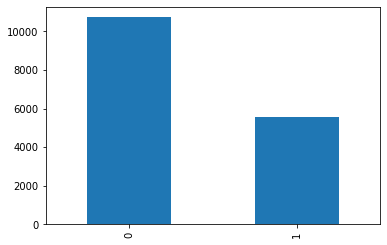

In [4]:
dataset.label.value_counts().plot(kind='bar')

In [5]:
print(dataset.groupby('label').size().reset_index(name = 'count'))

   label  count
0      0  10726
1      1   5564


In [6]:
print(dataset.isnull().values.any())

False


In [7]:
X = dataset.drop(['label'], axis=1)
y = dataset['label']

In [8]:
X

,ALG13.KEGG_N_GLYCAN_BIOSYNTHESIS,DOLPP1.KEGG_N_GLYCAN_BIOSYNTHESIS,RPN1.KEGG_N_GLYCAN_BIOSYNTHESIS,ALG14.KEGG_N_GLYCAN_BIOSYNTHESIS,MAN1B1.KEGG_N_GLYCAN_BIOSYNTHESIS,ALG3.KEGG_N_GLYCAN_BIOSYNTHESIS,B4GALT1.KEGG_N_GLYCAN_BIOSYNTHESIS,MGAT5.KEGG_N_GLYCAN_BIOSYNTHESIS,RPN2.KEGG_N_GLYCAN_BIOSYNTHESIS,STT3A.KEGG_N_GLYCAN_BIOSYNTHESIS,...,MYH4.KEGG_VIRAL_MYOCARDITIS,MYH7.KEGG_VIRAL_MYOCARDITIS,MYH6.KEGG_VIRAL_MYOCARDITIS,MYH9.KEGG_VIRAL_MYOCARDITIS,MYH8.KEGG_VIRAL_MYOCARDITIS,MYH11.KEGG_VIRAL_MYOCARDITIS,FYN.KEGG_VIRAL_MYOCARDITIS,MYH10.KEGG_VIRAL_MYOCARDITIS,HLA-DRB1.KEGG_VIRAL_MYOCARDITIS,HLA-DRA.KEGG_VIRAL_MYOCARDITIS
B3_P3_M15,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.0,0.00,0.00,...,0.0,0.0,0.0,4.65,0.0,0.00,0.00,0.0,9.13,14.14
B6_P1_M15,0.00,0.00,0.00,0.0,7.24,0.00,7.36,0.0,0.00,0.00,...,0.0,0.0,0.0,8.52,0.0,0.00,0.00,0.0,9.19,13.09
D7_P2_M15,9.07,0.00,7.61,0.0,0.00,7.61,7.69,0.0,0.00,6.24,...,0.0,0.0,0.0,5.95,0.0,0.00,0.00,0.0,11.46,13.66
E11_P2_M15,0.00,0.00,0.00,0.0,0.00,0.00,5.08,0.0,0.00,0.00,...,0.0,0.0,0.0,8.43,0.0,0.00,9.40,0.0,6.96,0.00
F7_P1_M15,0.00,0.00,7.50,0.0,0.00,0.00,7.23,0.0,9.21,8.24,...,0.0,0.0,0.0,8.33,0.0,0.00,4.77,0.0,8.28,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B10_P8_M86_L001,6.58,0.00,10.02,0.0,0.00,8.27,0.00,0.0,7.24,8.16,...,0.0,0.0,0.0,7.99,0.0,0.00,4.03,0.0,9.47,10.13
D1_P8_M86_L001,0.00,0.00,8.84,0.0,0.00,0.00,7.27,0.0,7.38,0.00,...,0.0,0.0,0.0,6.18,0.0,3.01,7.41,0.0,9.87,11.36
D7_P8_M86_L001,0.00,0.00,4.05,0.0,0.00,0.00,6.34,0.0,0.00,0.00,...,0.0,0.0,0.0,8.00,0.0,0.00,0.00,0.0,0.00,0.00
G7_P6_M86_L001,0.00,0.00,8.36,0.0,0.00,0.00,4.62,0.0,7.96,9.01,...,0.0,0.0,0.0,8.05,0.0,0.00,7.77,0.0,0.00,0.00


In [9]:
X.iloc[0,0]

0.0

In [10]:
y

B3_P3_M15          1
B6_P1_M15          1
D7_P2_M15          1
E11_P2_M15         1
F7_P1_M15          1
                  ..
B10_P8_M86_L001    0
D1_P8_M86_L001     0
D7_P8_M86_L001     0
G7_P6_M86_L001     0
H9_P9_M86_L001     0
Name: label, Length: 16290, dtype: int64

In [11]:
import pandas as pd

label = pd.read_csv('./patient.response.txt', sep='\t')
label

,characteristics,response,therapy
0,Post_P1,Responder,anti-PD1
1,Post_P1_2,Non-responder,anti-PD1
2,Pre_P2,Non-responder,anti-PD1
3,Post_P2,Non-responder,anti-PD1
4,Pre_P3,Non-responder,anti-PD1
5,Post_P3_2,Non-responder,anti-PD1
6,Pre_P4,Non-responder,anti-CTLA4+PD1
7,Post_P4,Responder,anti-CTLA4+PD1
8,Post_P5,Non-responder,anti-PD1
9,Post_P5_2,Responder,anti-PD1


In [12]:
label['response_therapy'] = label['response'].astype('str')+str('_')+label['therapy'].astype('str')
label

,characteristics,response,therapy,response_therapy
0,Post_P1,Responder,anti-PD1,Responder_anti-PD1
1,Post_P1_2,Non-responder,anti-PD1,Non-responder_anti-PD1
2,Pre_P2,Non-responder,anti-PD1,Non-responder_anti-PD1
3,Post_P2,Non-responder,anti-PD1,Non-responder_anti-PD1
4,Pre_P3,Non-responder,anti-PD1,Non-responder_anti-PD1
5,Post_P3_2,Non-responder,anti-PD1,Non-responder_anti-PD1
6,Pre_P4,Non-responder,anti-CTLA4+PD1,Non-responder_anti-CTLA4+PD1
7,Post_P4,Responder,anti-CTLA4+PD1,Responder_anti-CTLA4+PD1
8,Post_P5,Non-responder,anti-PD1,Non-responder_anti-PD1
9,Post_P5_2,Responder,anti-PD1,Responder_anti-PD1


In [13]:
label['response_therapy'].unique()

array(['Responder_anti-PD1', 'Non-responder_anti-PD1',
       'Non-responder_anti-CTLA4+PD1', 'Responder_anti-CTLA4+PD1',
       'Non-responder_anti-CTLA4', 'Responder_anti-CTLA4'], dtype=object)

# Modify dataset

## the number of pathway

In [14]:
gene = X.columns.str.split('.').str[0].tolist()
gene_unique = set(gene)
print('Gene 종류:', len(set(gene_unique)))

pathway = X.columns.str.split('.').str[1].tolist()
pathway_unique = set(pathway)
print('Pathway 종류:', len(set(pathway_unique)))

Gene 종류: 5030
Pathway 종류: 186


In [15]:
gene_pathway = pd.DataFrame({'gene':X.columns.str.split('.').str[0], 'pathway':X.columns.str.split('.').str[1]})
gene_pathway

,gene,pathway
0,ALG13,KEGG_N_GLYCAN_BIOSYNTHESIS
1,DOLPP1,KEGG_N_GLYCAN_BIOSYNTHESIS
2,RPN1,KEGG_N_GLYCAN_BIOSYNTHESIS
3,ALG14,KEGG_N_GLYCAN_BIOSYNTHESIS
4,MAN1B1,KEGG_N_GLYCAN_BIOSYNTHESIS
...,...,...
12408,MYH11,KEGG_VIRAL_MYOCARDITIS
12409,FYN,KEGG_VIRAL_MYOCARDITIS
12410,MYH10,KEGG_VIRAL_MYOCARDITIS
12411,HLA-DRB1,KEGG_VIRAL_MYOCARDITIS


In [16]:
for i in pathway_unique:
    if len(gene_pathway[gene_pathway['pathway']==i]) > 300:
        print((gene_pathway[gene_pathway['pathway']==i]))

         gene                      pathway
9019    CALM2  KEGG_OLFACTORY_TRANSDUCTION
9020    CALM1  KEGG_OLFACTORY_TRANSDUCTION
9021   OR11H4  KEGG_OLFACTORY_TRANSDUCTION
9022   OR52W1  KEGG_OLFACTORY_TRANSDUCTION
9023   OR5AU1  KEGG_OLFACTORY_TRANSDUCTION
...       ...                          ...
9397    OR2G6  KEGG_OLFACTORY_TRANSDUCTION
9398    OR6K3  KEGG_OLFACTORY_TRANSDUCTION
9399    OR6Y1  KEGG_OLFACTORY_TRANSDUCTION
9400  OR10AD1  KEGG_OLFACTORY_TRANSDUCTION
9401   OR4K15  KEGG_OLFACTORY_TRANSDUCTION

[383 rows x 2 columns]
         gene                  pathway
11008     JUN  KEGG_PATHWAYS_IN_CANCER
11009   STAT3  KEGG_PATHWAYS_IN_CANCER
11010     TFG  KEGG_PATHWAYS_IN_CANCER
11011   STAT1  KEGG_PATHWAYS_IN_CANCER
11012     HGF  KEGG_PATHWAYS_IN_CANCER
...       ...                      ...
11324   CKS1B  KEGG_PATHWAYS_IN_CANCER
11325     IL6  KEGG_PATHWAYS_IN_CANCER
11326   NTRK1  KEGG_PATHWAYS_IN_CANCER
11327  PIK3R1  KEGG_PATHWAYS_IN_CANCER
11328  PIK3R2  KEGG_PATHWAYS_IN

In [17]:
print('한 Pathway 당 가장 많은 gene 종류:', len(gene_pathway[gene_pathway['pathway']=='KEGG_OLFACTORY_TRANSDUCTION']))

한 Pathway 당 가장 많은 gene 종류: 383


In [18]:
print(383*186)

71238


## gene x pathway 2d

In [19]:
cell_list = X.index.to_list()
cell_list

['B3_P3_M15',
 'B6_P1_M15',
 'D7_P2_M15',
 'E11_P2_M15',
 'F7_P1_M15',
 'G11_P5_M15',
 'H10_P1_M15',
 'H2_P1_M15',
 'A7_P2_M15',
 'A9_P1_M15',
 'B2_P2_M15',
 'C11_P2_M15',
 'C6_P2_M15',
 'C6_P5_M15',
 'D12_P5_M15',
 'E1_P2_M15',
 'H10_P5_M15',
 'H7_P2_M15',
 'B10_P4_M15',
 'B3_P6_M15',
 'C11_P5_M15',
 'D10_P5_M15',
 'D1_P1_M15',
 'D6_P1_M15',
 'F2_P1_M15',
 'F6_P5_M15',
 'F8_P6_M15',
 'G12_P2_M15',
 'G1_P6_M15',
 'G3_P5_M15',
 'G7_P5_M15',
 'H1_P6_M15',
 'H3_P1_M15',
 'A10_P6_M15',
 'A12_P1_M15',
 'A12_P2_M15',
 'A4_P3_M15',
 'A8_P1_M15',
 'B3_P2_M15',
 'B4_P3_M15',
 'B7_P6_M15',
 'B9_P6_M15',
 'C10_P2_M15',
 'C2_P2_M15',
 'C4_P6_M15',
 'C5_P1_M15',
 'C8_P1_M15',
 'C9_P1_M15',
 'C9_P5_M15',
 'D6_P6_M15',
 'E11_P6_M15',
 'E12_P4_M15',
 'E1_P5_M15',
 'E4_P5_M15',
 'E6_P5_M15',
 'E8_P2_M15',
 'E9_P6_M15',
 'F11_P5_M15',
 'F12_P1_M15',
 'F12_P6_M14',
 'F3_P1_M15',
 'F7_P6_M15',
 'G10_P1_M15',
 'G10_P6_M15',
 'G3_P3_M15',
 'G6_P6_M15',
 'H11_P1_M15',
 'H12_P2_M15',
 'H12_P5_M15',
 'H12_P6_M

In [20]:
df = pd.DataFrame(index=range(0,383), columns=pathway_unique)
pathway_list = df.columns.to_list()
pathway_list

['KEGG_RNA_DEGRADATION',
 'KEGG_ANTIGEN_PROCESSING_AND_PRESENTATION',
 'KEGG_EPITHELIAL_CELL_SIGNALING_IN_HELICOBACTER_PYLORI_INFECTION',
 'KEGG_ASCORBATE_AND_ALDARATE_METABOLISM',
 'KEGG_GLYOXYLATE_AND_DICARBOXYLATE_METABOLISM',
 'KEGG_NOTCH_SIGNALING_PATHWAY',
 'KEGG_PROTEIN_EXPORT',
 'KEGG_VALINE_LEUCINE_AND_ISOLEUCINE_DEGRADATION',
 'KEGG_MAPK_SIGNALING_PATHWAY',
 'KEGG_PROGESTERONE_MEDIATED_OOCYTE_MATURATION',
 'KEGG_GLYCOSPHINGOLIPID_BIOSYNTHESIS_LACTO_AND_NEOLACTO_SERIES',
 'KEGG_LEISHMANIA_INFECTION',
 'KEGG_PROSTATE_CANCER',
 'KEGG_TERPENOID_BACKBONE_BIOSYNTHESIS',
 'KEGG_FC_GAMMA_R_MEDIATED_PHAGOCYTOSIS',
 'KEGG_INOSITOL_PHOSPHATE_METABOLISM',
 'KEGG_VIBRIO_CHOLERAE_INFECTION',
 'KEGG_NICOTINATE_AND_NICOTINAMIDE_METABOLISM',
 'KEGG_VALINE_LEUCINE_AND_ISOLEUCINE_BIOSYNTHESIS',
 'KEGG_DRUG_METABOLISM_OTHER_ENZYMES',
 'KEGG_PRIMARY_IMMUNODEFICIENCY',
 'KEGG_RNA_POLYMERASE',
 'KEGG_NEUROTROPHIN_SIGNALING_PATHWAY',
 'KEGG_PANCREATIC_CANCER',
 'KEGG_CELL_ADHESION_MOLECULES_CAMS',
 

In [21]:
'''
# gene x pathway 데이터프레임을 가진 cell list 만들기

dfs = []

for cell in tqdm(cell_list, desc='outer', position=0):
    df = pd.DataFrame(index=range(0,383), columns=pathway_list)
    
    for pw in pathway_list:
        temp = X.loc[cell][X.loc[cell].index.str.contains(pw)].values
        df[pw] = np.pad(temp, (0, 383-len(temp)), 'constant', constant_values=0)

    dfs.append(df)
'''


"\n# gene x pathway 데이터프레임을 가진 cell list 만들기\n\ndfs = []\n\nfor cell in tqdm(cell_list, desc='outer', position=0):\n    df = pd.DataFrame(index=range(0,383), columns=pathway_list)\n    \n    for pw in pathway_list:\n        temp = X.loc[cell][X.loc[cell].index.str.contains(pw)].values\n        df[pw] = np.pad(temp, (0, 383-len(temp)), 'constant', constant_values=0)\n\n    dfs.append(df)\n"

In [22]:
'''
# responder/nonresponder 폴더로 나누기

responder_path = '/home/taejoon/mount_ssd2/2023_scRNA/Responder/'
nonresponder_path = '/home/taejoon/mount_ssd2/2023_scRNA/Non_responder/'

for i in tqdm(range(len(dfs)), desc='outer', position=0):
    if y[i] == 1:
        dfs[i].to_csv(path_or_buf=responder_path+"{}.csv".format(y.index[i]))
    else:
        dfs[i].to_csv(path_or_buf=nonresponder_path+"{}.csv".format(y.index[i]))
'''


'\n# responder/nonresponder 폴더로 나누기\n\nresponder_path = \'/home/taejoon/mount_ssd2/2023_scRNA/Responder/\'\nnonresponder_path = \'/home/taejoon/mount_ssd2/2023_scRNA/Non_responder/\'\n\nfor i in tqdm(range(len(dfs)), desc=\'outer\', position=0):\n    if y[i] == 1:\n        dfs[i].to_csv(path_or_buf=responder_path+"{}.csv".format(y.index[i]))\n    else:\n        dfs[i].to_csv(path_or_buf=nonresponder_path+"{}.csv".format(y.index[i]))\n'

# load responder/non-responder dataset

In [23]:
responder_path = '/home/taejoon/mount_ssd2/2023_scRNA/Responder/'
nonresponder_path = '/home/taejoon/mount_ssd2/2023_scRNA/Non_responder/'

In [24]:
# responder cells 이름 리스트
responder_cells = os.listdir(responder_path)
print(responder_cells[:3])

# nonresponder cells 이름 리스트
nonresponder_cells = os.listdir(nonresponder_path)
print(nonresponder_cells[:3])

# 총 cells 개수
print('Responder cells: ', len(responder_cells))
print('Non-responder cells: ', len(nonresponder_cells))
print('Total cells: ', (len(responder_cells)+len(nonresponder_cells)))

['F12_P4_M47.csv', 'B9_P9_MMD5_L001.csv', 'D11_P7_M82_L001.csv']
['B12_P1_M39_T_enriched.csv', 'G6_P12_MMD2.36B_T_enriched.csv', 'F5_P5_M91_L001.csv']
Responder cells:  5564
Non-responder cells:  10726
Total cells:  16290


In [25]:
# responder cell numpy 형태로 변환

responder_cell_list_np = []

for i in tqdm(responder_cells):
    cell = pd.read_csv(f'./Responder/{i}', index_col='Unnamed: 0')
    cell_array = np.array(cell)
    responder_cell_list_np.append(cell_array)
    
X_responder = np.array(responder_cell_list_np)
print(X_responder.shape)

np.save('X_responder.npy', X_responder)

y_responder = np.ones(5564, dtype='float64')
print(len(y_responder))


100%|██████████| 5564/5564 [00:42<00:00, 131.55it/s]


(5564, 383, 186)
5564


In [26]:
# nonresponder cell numpy 형태로 변환

nonresponder_cell_list_np = []

for i in tqdm(nonresponder_cells):
    cell = pd.read_csv(f'./Non_responder/{i}', index_col='Unnamed: 0')
    cell_array = np.array(cell)
    nonresponder_cell_list_np.append(cell_array)
    
X_nonresponder = np.array(nonresponder_cell_list_np)
print(X_nonresponder.shape)

np.save('X_nonresponder.npy', X_nonresponder)

y_nonresponder = np.zeros(10726, dtype='float64')
print(len(y_nonresponder))


100%|██████████| 10726/10726 [01:37<00:00, 110.11it/s]


(10726, 383, 186)
10726


In [27]:
'''
X = np.concatenate((X_responder, X_nonresponder), axis=0)
y = np.concatenate((y_responder, y_nonresponder), axis=None)
'''


'\nX = np.concatenate((X_responder, X_nonresponder), axis=0)\ny = np.concatenate((y_responder, y_nonresponder), axis=None)\n'

In [28]:
'''
np.save('X.npy', X)
np.save('y.npy', y)
'''


"\nnp.save('X.npy', X)\nnp.save('y.npy', y)\n"

In [29]:
X = np.load('X.npy')
y = np.load('y.npy')

In [30]:
print(X.shape)
print(y.shape)

(16290, 383, 186)
(16290,)


## Train & Test split

In [31]:
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit

X_tr, X_test, y_tr, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, stratify=y, random_state=25)

X_train, X_val, y_train, y_val = train_test_split(X_tr, y_tr, test_size=0.2, shuffle=True, stratify=y_tr, random_state=25)

In [32]:
print(X_train.shape)
print(X_test.shape)
print(X_val.shape)

(10425, 383, 186)
(3258, 383, 186)
(2607, 383, 186)


In [33]:
print(y_train.shape)
print(y_test.shape)
print(y_val.shape)

(10425,)
(3258,)
(2607,)


# Conv2D Model

In [34]:
dropout_ratio = 0.3

inputs = keras.Input(shape=(383, 186, 1))

x = Conv2D(filters=128, kernel_size=(3,3), padding='same', input_shape=(383, 186, 1))(inputs) 
#x = BatchNormalization()(x)
x = Activation("relu")(x)
x = Dropout(dropout_ratio)(x)
x = MaxPooling2D(pool_size=(2,2))(x)

x = Conv2D(filters=32, kernel_size=(3,3), padding='same')(x)
#x = BatchNormalization()(x)
x = Activation("relu")(x)
x = Dropout(dropout_ratio)(x)
x = MaxPooling2D(pool_size=(2,2))(x)

x = Conv2D(filters=16, kernel_size=(3,3), padding='same')(x)
#x = BatchNormalization()(x)
x = Activation("relu")(x)
x = Dropout(dropout_ratio)(x)
x = MaxPooling2D(pool_size=(2,2))(x)

x = Flatten()(x)
x = Dropout(dropout_ratio)(x)
#x = GlobalMaxPooling2D()(x)

x = Dense(32)(x)
x = Activation("relu")(x)
x = Dropout(dropout_ratio)(x)

x = Dense(1)(x)
out = Activation("sigmoid")(x)

es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=3)
mc = ModelCheckpoint('best_model.h5', monitor='val_acc', mode='max', verbose=1, save_best_only=True)

model = Model(inputs=inputs, outputs=out)

model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 383, 186, 1)]     0         
                                                                 
 conv2d (Conv2D)             (None, 383, 186, 128)     1280      
                                                                 
 activation (Activation)     (None, 383, 186, 128)     0         
                                                                 
 dropout (Dropout)           (None, 383, 186, 128)     0         
                                                                 
 max_pooling2d (MaxPooling2D  (None, 191, 93, 128)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 191, 93, 32)       36896     
                                                             

In [35]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate = 1e-4), 
              loss='binary_crossentropy', 
              metrics=['acc'])

In [36]:
history = model.fit(X_train, y_train,
                    epochs=30,
                    validation_data=(X_val, y_val), 
                    callbacks=[es, mc])

Epoch 1/30
326/326 [==============================] - ETA: 0s - loss: 0.6065 - acc: 0.6729
Epoch 1: val_acc improved from -inf to 0.69313, saving model to best_model.h5
326/326 [==============================] - 27s 71ms/step - loss: 0.6065 - acc: 0.6729 - val_loss: 0.5802 - val_acc: 0.6931
Epoch 2/30
325/326 [============================>.] - ETA: 0s - loss: 0.5649 - acc: 0.7070
Epoch 2: val_acc did not improve from 0.69313
326/326 [==============================] - 21s 66ms/step - loss: 0.5648 - acc: 0.7071 - val_loss: 0.5780 - val_acc: 0.6720
Epoch 3/30
325/326 [============================>.] - ETA: 0s - loss: 0.5511 - acc: 0.7113
Epoch 3: val_acc improved from 0.69313 to 0.72535, saving model to best_model.h5
326/326 [==============================] - 22s 69ms/step - loss: 0.5508 - acc: 0.7117 - val_loss: 0.5585 - val_acc: 0.7254
Epoch 4/30
325/326 [============================>.] - ETA: 0s - loss: 0.5428 - acc: 0.7235
Epoch 4: val_acc improved from 0.72535 to 0.73379, saving mode

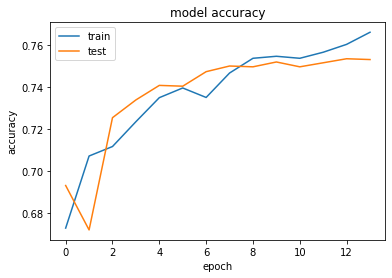

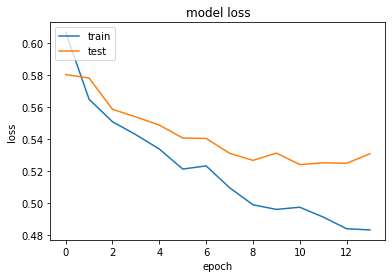

0.7533563375473022


In [37]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

print(np.max(history.history['val_acc']))

In [38]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print('Test loss:', loss)
print('Test acc:', accuracy)

Test loss: 0.5298731923103333
Test acc: 0.7403314709663391


# Grad-CAM

* https://keras.io/examples/vision/grad_cam/ 
* https://hiddenbeginner.github.io/deeplearning/2022/02/15/tutorial_gradcam_tensorflow.html

In [39]:
def make_grad_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )
    
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]
        
    grads = tape.gradient(class_channel, last_conv_layer_output)
    
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    
    last_conv_layer_output = last_conv_layer_output[0]
    
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

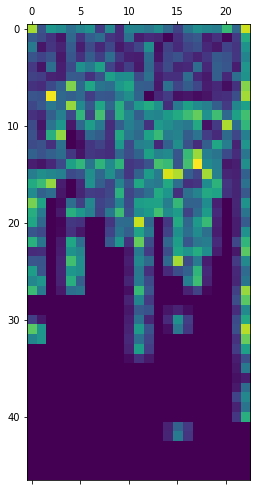

In [117]:
heatmap = make_grad_heatmap(X_val[0:1], model, 'max_pooling2d_2')
plt.matshow(heatmap)
plt.show()

In [41]:
def display_gradcam_with_img(img, heatmap, alpha=0.4):
    heatmap = np.uint8(255 * heatmap)
    
    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    
    jet_heatmap = keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = keras.preprocessing.image.img_to_array(jet_heatmap)
    
    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = np.uint8(superimposed_img)
    
    fig, axes = plt.subplots(1, 3, figsize=(15,10))
    axes[0].imshow(img)
    axes[1].imshow(heatmap)
    axes[2].imshow(superimposed_img)
    #for ax in axes:
        #ax.axis('off')

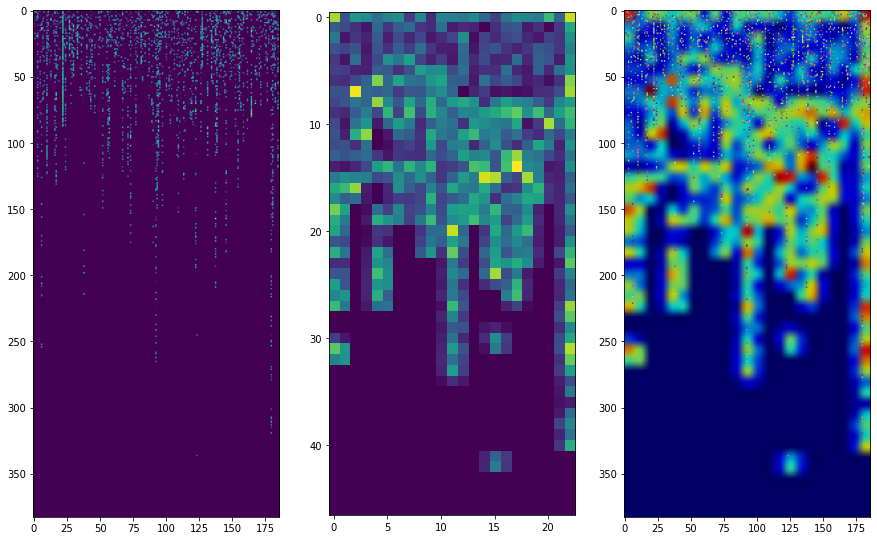

In [114]:
img = X_val[0].reshape(383,186,1)
heatmap = make_grad_heatmap(img[np.newaxis], model, 'max_pooling2d_2')

k = display_gradcam_with_img(255 * img, heatmap, alpha=0.8)

## Responder / Non-responder 환자 activation map 비교

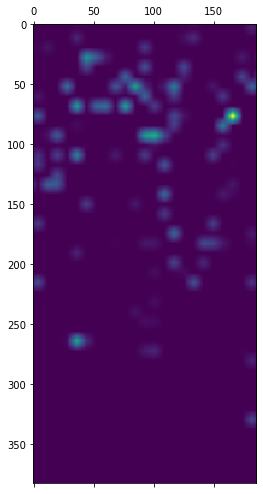

In [43]:
img = X_responder[0].reshape(383,186,1)
heatmap = make_grad_heatmap(img[np.newaxis], model, 'max_pooling2d_2')
responder = resize(heatmap, (383,186))

plt.matshow(responder)
plt.show()

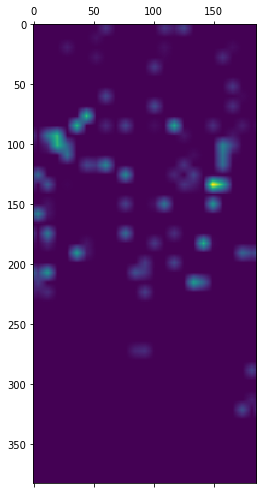

In [44]:
img = X_nonresponder[0].reshape(383,186,1)
heatmap = make_grad_heatmap(img[np.newaxis], model, 'max_pooling2d_2')
nonresponder = resize(heatmap, (383,186))

plt.matshow(nonresponder)
plt.show()

## Responders' heatmap 가장 많이 영향을 미친 유전자 

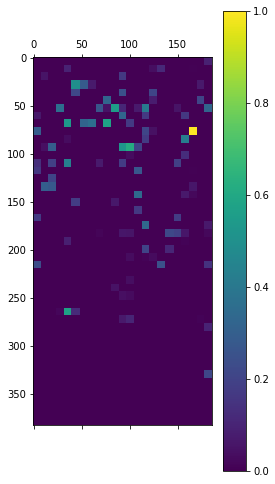

In [112]:
img = X_responder[0].reshape(383,186,1)
heatmap = make_grad_heatmap(img[np.newaxis], model, 'max_pooling2d_2')
im = Image.fromarray(heatmap)
im = im.resize((186,383), Image.NEAREST)
plt.matshow(im)
plt.colorbar()

In [47]:
# 데이터프레임 형태로 

responder_index_path = pd.DataFrame()

for i in tqdm(range(len(X_responder))):
    img = X_responder[i].reshape(383,186,1)
    heatmap = make_grad_heatmap(img[np.newaxis], model, 'max_pooling2d_2')
    im = Image.fromarray(heatmap)
    im = im.resize((186,383), Image.NEAREST)
    responder = np.array(im)

    # res 0.9 이상 
    responder_df = pd.DataFrame(responder, columns=pathway_list)
        
    for index in range(len(responder_df)):
        for path in pathway_list:
            if responder_df.loc[index, path]>=0.9:
                index_path = pd.DataFrame([[index, path, i]],columns=['gene_index','pathway','cell_index'])
                responder_index_path = pd.concat([responder_index_path, index_path], ignore_index=True)
            else: pass

# scale 값 0.9 이상인 pair dataframe
responder_index_path    

100%|██████████| 5564/5564 [1:13:57<00:00,  1.25it/s]


,gene_index,pathway,cell_index
0,73,KEGG_ETHER_LIPID_METABOLISM,0
1,73,KEGG_LYSINE_DEGRADATION,0
2,73,KEGG_GLYCEROLIPID_METABOLISM,0
3,73,KEGG_CELL_CYCLE,0
4,73,KEGG_BUTANOATE_METABOLISM,0
...,...,...,...
737669,121,KEGG_NOD_LIKE_RECEPTOR_SIGNALING_PATHWAY,5563
737670,121,KEGG_FOCAL_ADHESION,5563
737671,121,KEGG_OXIDATIVE_PHOSPHORYLATION,5563
737672,121,KEGG_SNARE_INTERACTIONS_IN_VESICULAR_TRANSPORT,5563


In [48]:
### image 길이에 맞춰서 편집

for i in tqdm(range(len(responder_index_path))):
    df = gene_pathway[gene_pathway['pathway']==responder_index_path.loc[i][1]].reset_index(drop=True)
    
    if responder_index_path.loc[i][0] < len(df): 
        responder_index_path.loc[i, 'gene'] = df['gene'][responder_index_path.loc[i][0]]
        
    else : pass

responder_index_path

100%|██████████| 737674/737674 [12:44<00:00, 965.21it/s] 


,gene_index,pathway,cell_index,gene
0,73,KEGG_ETHER_LIPID_METABOLISM,0,NaN
1,73,KEGG_LYSINE_DEGRADATION,0,NaN
2,73,KEGG_GLYCEROLIPID_METABOLISM,0,NaN
3,73,KEGG_CELL_CYCLE,0,SKP2
4,73,KEGG_BUTANOATE_METABOLISM,0,NaN
...,...,...,...,...
737669,121,KEGG_NOD_LIKE_RECEPTOR_SIGNALING_PATHWAY,5563,NaN
737670,121,KEGG_FOCAL_ADHESION,5563,ITGB7
737671,121,KEGG_OXIDATIVE_PHOSPHORYLATION,5563,NaN
737672,121,KEGG_SNARE_INTERACTIONS_IN_VESICULAR_TRANSPORT,5563,NaN


In [70]:
### NaN 값 제외

print(responder_index_path.isna().sum())

selected_responder = responder_index_path.dropna(axis=0, how='any').reset_index(drop=True)
selected_responder

gene_index         0
pathway            0
cell_index         0
gene          516491
dtype: int64


,gene_index,pathway,cell_index,gene
0,73,KEGG_CELL_CYCLE,0,SKP2
1,73,KEGG_PHOSPHATIDYLINOSITOL_SIGNALING_SYSTEM,0,PIK3R2
2,74,KEGG_CELL_CYCLE,0,CUL1
3,74,KEGG_PHOSPHATIDYLINOSITOL_SIGNALING_SYSTEM,0,CALML6
4,75,KEGG_CELL_CYCLE,0,SMAD3
...,...,...,...,...
221178,119,KEGG_FOCAL_ADHESION,5563,ITGB6
221179,120,KEGG_UBIQUITIN_MEDIATED_PROTEOLYSIS,5563,ANAPC13
221180,120,KEGG_FOCAL_ADHESION,5563,DOCK1
221181,121,KEGG_UBIQUITIN_MEDIATED_PROTEOLYSIS,5563,FBXO2


In [104]:
### Cell index - Cell 이름 매칭
responder_cells_wo_csv = [w[:-4] for w in responder_cells]

res_dict = { i:responder_cells_wo_csv[i] for i in range(len(responder_cells_wo_csv)) }
selected_responder['cell'] = selected_responder['cell_index'].map(res_dict)

selected_responder.to_csv('selected_responder.csv')

In [108]:
### Responders' heatmap 중 가장 많이 영향을 미친 gene-pathway

sort = ['cell_index','cell','gene_index','gene','pathway']
responder_dataframe = selected_responder[sort].drop(['cell_index','gene_index'], axis=1)
responder_dataframe

,cell,gene,pathway
0,F12_P4_M47,SKP2,KEGG_CELL_CYCLE
1,F12_P4_M47,PIK3R2,KEGG_PHOSPHATIDYLINOSITOL_SIGNALING_SYSTEM
2,F12_P4_M47,CUL1,KEGG_CELL_CYCLE
3,F12_P4_M47,CALML6,KEGG_PHOSPHATIDYLINOSITOL_SIGNALING_SYSTEM
4,F12_P4_M47,SMAD3,KEGG_CELL_CYCLE
...,...,...,...
221178,B8_P1_M41_L001,ITGB6,KEGG_FOCAL_ADHESION
221179,B8_P1_M41_L001,ANAPC13,KEGG_UBIQUITIN_MEDIATED_PROTEOLYSIS
221180,B8_P1_M41_L001,DOCK1,KEGG_FOCAL_ADHESION
221181,B8_P1_M41_L001,FBXO2,KEGG_UBIQUITIN_MEDIATED_PROTEOLYSIS


In [256]:
responder_dataframe.value_counts(subset=['pathway','gene'], sort=True)[:30]

pathway                              gene  
KEGG_FOCAL_ADHESION                  COL4A2    630
KEGG_UBIQUITIN_MEDIATED_PROTEOLYSIS  CDC23     630
KEGG_FOCAL_ADHESION                  COL3A1    630
                                     BRAF      630
                                     COL4A4    630
KEGG_OXIDATIVE_PHOSPHORYLATION       COX11     630
                                     COX15     630
                                     CYC1      630
KEGG_FOCAL_ADHESION                  VAV1      630
                                     PDPK1     630
KEGG_OXIDATIVE_PHOSPHORYLATION       NDUFB4    630
                                     NDUFB5    630
KEGG_FOCAL_ADHESION                  PARVB     630
KEGG_OXIDATIVE_PHOSPHORYLATION       NDUFS2    630
                                     NDUFS3    630
                                     NDUFS5    630
KEGG_FOCAL_ADHESION                  COL4A1    630
KEGG_UBIQUITIN_MEDIATED_PROTEOLYSIS  CBLB      630
                                     A

In [110]:
### excel로 저장
responder_dataframe.to_excel('responder_dataframe.xlsx', index=False)

100%|██████████| 5564/5564 [01:38<00:00, 56.57it/s]


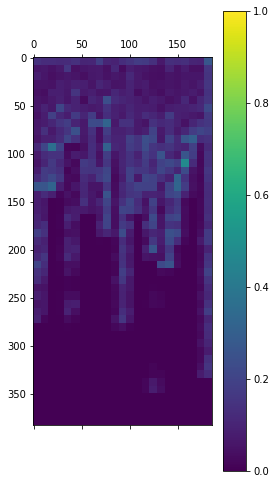

In [280]:
########### Responders' heatmap average ##############
heatmap_avg = np.empty(shape=(0,47,23))

for i in tqdm(range(len(X_responder))):
    img = X_responder[i].reshape(383,186,1)
    heatmap = make_grad_heatmap(img[np.newaxis], model, 'max_pooling2d_2')
    
    heatmap_avg = np.vstack([heatmap_avg, heatmap[None,:]])
    
res_heatmap_avg = np.nanmean(heatmap_avg, axis=0)

im = Image.fromarray(res_heatmap_avg)
im = im.resize((186,383), Image.NEAREST)

res_heatmap = np.array(im)

plt.matshow(im, vmin=0.0, vmax=1.0)
plt.colorbar()

In [214]:
# 데이터프레임 형태로 

res_heatmap_index_path = pd.DataFrame()

# res 0.9 이상 
res_heatmap_df = pd.DataFrame(res_heatmap, columns=pathway_list)
        
for index in range(len(res_heatmap_df)):
    for path in pathway_list:
        if res_heatmap_df.loc[index, path]>=0.4:
            index_path = pd.DataFrame([[index, path]],columns=['gene_index','pathway'])
            res_heatmap_index_path = pd.concat([res_heatmap_index_path, index_path], ignore_index=True)
        else: pass

# scale 값 0.9 이상인 pair dataframe
res_heatmap_index_path    

,gene_index,pathway
0,106,KEGG_UBIQUITIN_MEDIATED_PROTEOLYSIS
1,106,KEGG_MTOR_SIGNALING_PATHWAY
2,106,KEGG_THYROID_CANCER
3,106,KEGG_NOD_LIKE_RECEPTOR_SIGNALING_PATHWAY
4,106,KEGG_FOCAL_ADHESION
...,...,...
59,113,KEGG_NOD_LIKE_RECEPTOR_SIGNALING_PATHWAY
60,113,KEGG_FOCAL_ADHESION
61,113,KEGG_OXIDATIVE_PHOSPHORYLATION
62,113,KEGG_SNARE_INTERACTIONS_IN_VESICULAR_TRANSPORT


In [215]:
### image 길이에 맞춰서 편집

for i in tqdm(range(len(res_heatmap_index_path))):
    df = gene_pathway[gene_pathway['pathway']==res_heatmap_index_path.loc[i][1]].reset_index(drop=True)
    
    if res_heatmap_index_path.loc[i][0] < len(df): 
        res_heatmap_index_path.loc[i, 'gene'] = df['gene'][res_heatmap_index_path.loc[i][0]]
        
    else : pass

res_heatmap_index_path

100%|██████████| 64/64 [00:00<00:00, 738.78it/s]


,gene_index,pathway,gene
0,106,KEGG_UBIQUITIN_MEDIATED_PROTEOLYSIS,CUL4A
1,106,KEGG_MTOR_SIGNALING_PATHWAY,NaN
2,106,KEGG_THYROID_CANCER,NaN
3,106,KEGG_NOD_LIKE_RECEPTOR_SIGNALING_PATHWAY,NaN
4,106,KEGG_FOCAL_ADHESION,COL3A1
...,...,...,...
59,113,KEGG_NOD_LIKE_RECEPTOR_SIGNALING_PATHWAY,NaN
60,113,KEGG_FOCAL_ADHESION,PDPK1
61,113,KEGG_OXIDATIVE_PHOSPHORYLATION,COX15
62,113,KEGG_SNARE_INTERACTIONS_IN_VESICULAR_TRANSPORT,NaN


In [219]:
### NaN 값 제외

print(res_heatmap_index_path.isna().sum())

selected_heatmap_responder = res_heatmap_index_path.dropna(axis=0, how='any').reset_index(drop=True)
selected_heatmap_responder

gene_index     0
pathway        0
gene          40
dtype: int64


,gene_index,pathway,gene
0,106,KEGG_UBIQUITIN_MEDIATED_PROTEOLYSIS,CUL4A
1,106,KEGG_FOCAL_ADHESION,COL3A1
2,106,KEGG_OXIDATIVE_PHOSPHORYLATION,NDUFS5
3,107,KEGG_UBIQUITIN_MEDIATED_PROTEOLYSIS,CUL4B
4,107,KEGG_FOCAL_ADHESION,COL4A1
5,107,KEGG_OXIDATIVE_PHOSPHORYLATION,NDUFS2
6,108,KEGG_UBIQUITIN_MEDIATED_PROTEOLYSIS,ANAPC2
7,108,KEGG_FOCAL_ADHESION,PARVB
8,108,KEGG_OXIDATIVE_PHOSPHORYLATION,NDUFB4
9,109,KEGG_UBIQUITIN_MEDIATED_PROTEOLYSIS,FANCL


In [260]:
### Responders' heatmap 중 가장 많이 영향을 미친 gene-pathway
responder_heatmap_dataframe[['pathway','gene']].sort_values(by='pathway')

,pathway,gene
1,KEGG_FOCAL_ADHESION,COL3A1
19,KEGG_FOCAL_ADHESION,VAV1
4,KEGG_FOCAL_ADHESION,COL4A1
16,KEGG_FOCAL_ADHESION,COL4A4
7,KEGG_FOCAL_ADHESION,PARVB
13,KEGG_FOCAL_ADHESION,BRAF
10,KEGG_FOCAL_ADHESION,COL4A2
22,KEGG_FOCAL_ADHESION,PDPK1
11,KEGG_OXIDATIVE_PHOSPHORYLATION,NDUFS3
20,KEGG_OXIDATIVE_PHOSPHORYLATION,COX11


In [53]:
'''
res_index_path = []

for i in tqdm(range(len(X_responder))):
    img = X_responder[i].reshape(383,186,1)
    heatmap = make_grad_heatmap(img[np.newaxis], model, 'max_pooling2d_2')
    responder = resize(heatmap, (383,186))

    # res 0.9 이상 
    responder_df = pd.DataFrame(responder, columns=pathway_list)

    index_path = []

    for index in range(len(responder_df)):
        for path in pathway_list:
            if responder_df.loc[index, path]>=0.9:
                pair = (index, path)
                index_path.append(pair)
            else: pass

    # scale 값 0.9 이상인 페어 리스트
    res_index_path.extend(index_path)
    
### 리스트 저장하기
with open("responder_index_path","wb") as f:
    pickle.dump(res_index_path, f)

### 리스트 불러오기 
with open("responder_index_path","rb") as f:
    res_index_path = pickle.load(f)

### image 길이에 맞춰서 편집
res_selected = []

for i in tqdm(range(len(res_index_path))):
    df = gene_pathway[gene_pathway['pathway']==res_index_path[i][1]].reset_index(drop=True)
    
    if res_index_path[i][0] < len(df): 
        gene = df['gene'][res_index_path[i][0]]
        pair = (gene, res_index_path[i][1])
        res_selected.append(pair)
    else : pass
    
### 가장 많은 영향을 미친 유전자 Top 10
res_counter = Counter(res_selected)

res_top_10_gene = res_counter.most_common(n=10)
res_top_10_gene

'''

'\nres_index_path = []\n\nfor i in tqdm(range(len(X_responder))):\n    img = X_responder[i].reshape(383,186,1)\n    heatmap = make_grad_heatmap(img[np.newaxis], model, \'max_pooling2d_2\')\n    responder = resize(heatmap, (383,186))\n\n    # res 0.9 이상 \n    responder_df = pd.DataFrame(responder, columns=pathway_list)\n\n    index_path = []\n\n    for index in range(len(responder_df)):\n        for path in pathway_list:\n            if responder_df.loc[index, path]>=0.9:\n                pair = (index, path)\n                index_path.append(pair)\n            else: pass\n\n    # scale 값 0.9 이상인 페어 리스트\n    res_index_path.extend(index_path)\n    \n### 리스트 저장하기\nwith open("responder_index_path","wb") as f:\n    pickle.dump(res_index_path, f)\n\n### 리스트 불러오기 \nwith open("responder_index_path","rb") as f:\n    res_index_path = pickle.load(f)\n\n### image 길이에 맞춰서 편집\nres_selected = []\n\nfor i in tqdm(range(len(res_index_path))):\n    df = gene_pathway[gene_pathway[\'pathway\']==res_index

## Non-responders' heatmap 가장 많이 영향을 미친 유전자 

In [54]:
'''
non_index_path = []

for i in tqdm(range(len(X_nonresponder))):
    img = X_nonresponder[i].reshape(383,186,1)
    heatmap = make_grad_heatmap(img[np.newaxis], model, 'max_pooling2d_2')
    nonresponder = resize(heatmap, (383,186))

    # res 0.9 이상 
    nonresponder_df = pd.DataFrame(nonresponder, columns=pathway_list)

    index_path = []

    for index in range(len(nonresponder_df)):
        for path in pathway_list:
            if nonresponder_df.loc[index, path]>=0.9:
                pair = (index, path)
                index_path.append(pair)
            else: pass

    # scale 값 0.9 이상인 페어 리스트
    non_index_path.extend(index_path)
    
### 리스트 저장하기
with open("nonresponder_index_path","wb") as f:
    pickle.dump(non_index_path, f)
### 리스트 불러오기 
with open("nonresponder_index_path","rb") as f:
    non_index_path = pickle.load(f)
    

### image 길이에 맞춰서 편집
non_selected = []

for i in tqdm(range(len(non_index_path))):
    df = gene_pathway[gene_pathway['pathway']==non_index_path[i][1]].reset_index(drop=True)
    
    if non_index_path[i][0] < len(df): 
        gene = df['gene'][non_index_path[i][0]]
        pair = (gene, non_index_path[i][1])
        non_selected.append(pair)
    else : pass
    
### 가장 많은 영향을 미친 유전자 Top 10   
non_counter = Counter(non_selected)

non_top_10_gene = non_counter.most_common(n=10)
non_top_10_gene  

'''


'\nnon_index_path = []\n\nfor i in tqdm(range(len(X_nonresponder))):\n    img = X_nonresponder[i].reshape(383,186,1)\n    heatmap = make_grad_heatmap(img[np.newaxis], model, \'max_pooling2d_2\')\n    nonresponder = resize(heatmap, (383,186))\n\n    # res 0.9 이상 \n    nonresponder_df = pd.DataFrame(nonresponder, columns=pathway_list)\n\n    index_path = []\n\n    for index in range(len(nonresponder_df)):\n        for path in pathway_list:\n            if nonresponder_df.loc[index, path]>=0.9:\n                pair = (index, path)\n                index_path.append(pair)\n            else: pass\n\n    # scale 값 0.9 이상인 페어 리스트\n    non_index_path.extend(index_path)\n    \n### 리스트 저장하기\nwith open("nonresponder_index_path","wb") as f:\n    pickle.dump(non_index_path, f)\n### 리스트 불러오기 \nwith open("nonresponder_index_path","rb") as f:\n    non_index_path = pickle.load(f)\n    \n\n### image 길이에 맞춰서 편집\nnon_selected = []\n\nfor i in tqdm(range(len(non_index_path))):\n    df = gene_pathway[gene_

In [55]:
# 데이터프레임 형태로 

nonresponder_index_path = pd.DataFrame()

for i in tqdm(range(len(X_nonresponder))):
    img = X_nonresponder[i].reshape(383,186,1)
    heatmap = make_grad_heatmap(img[np.newaxis], model, 'max_pooling2d_2')
    im = Image.fromarray(heatmap)
    im = im.resize((186,383), Image.NEAREST)
    nonresponder = np.array(im)

    # res 0.9 이상 
    nonresponder_df = pd.DataFrame(nonresponder, columns=pathway_list)
        
    for index in range(len(nonresponder_df)):
        for path in pathway_list:
            if responder_df.loc[index, path]>=0.9:
                index_path = pd.DataFrame([[index, path, i]],columns=['gene_index','pathway','cell_index'])
                nonresponder_index_path = pd.concat([nonresponder_index_path, index_path], ignore_index=True)
            else: pass

# scale 값 0.9 이상인 pair dataframe
nonresponder_index_path    

100%|██████████| 10726/10726 [7:32:23<00:00,  2.53s/it] 


,gene_index,pathway,cell_index
0,41,KEGG_TRYPTOPHAN_METABOLISM,0
1,41,KEGG_ONE_CARBON_POOL_BY_FOLATE,0
2,41,KEGG_RENIN_ANGIOTENSIN_SYSTEM,0
3,41,KEGG_DILATED_CARDIOMYOPATHY,0
4,41,KEGG_ENDOCYTOSIS,0
...,...,...,...
2745851,121,KEGG_NOD_LIKE_RECEPTOR_SIGNALING_PATHWAY,10725
2745852,121,KEGG_FOCAL_ADHESION,10725
2745853,121,KEGG_OXIDATIVE_PHOSPHORYLATION,10725
2745854,121,KEGG_SNARE_INTERACTIONS_IN_VESICULAR_TRANSPORT,10725


In [92]:
### image 길이에 맞춰서 편집

for i in tqdm(range(len(nonresponder_index_path))):
    df = gene_pathway[gene_pathway['pathway']==nonresponder_index_path.loc[i][1]].reset_index(drop=True)
    
    if nonresponder_index_path.loc[i][0] < len(df): 
        nonresponder_index_path.loc[i, 'gene'] = df['gene'][nonresponder_index_path.loc[i][0]]
        
    else : pass

nonresponder_index_path

100%|██████████| 2745856/2745856 [47:46<00:00, 957.89it/s]


,gene_index,pathway,cell_index,gene
0,41,KEGG_TRYPTOPHAN_METABOLISM,0,NaN
1,41,KEGG_ONE_CARBON_POOL_BY_FOLATE,0,NaN
2,41,KEGG_RENIN_ANGIOTENSIN_SYSTEM,0,NaN
3,41,KEGG_DILATED_CARDIOMYOPATHY,0,ADCY4
4,41,KEGG_ENDOCYTOSIS,0,VPS4A
...,...,...,...,...
2745851,121,KEGG_NOD_LIKE_RECEPTOR_SIGNALING_PATHWAY,10725,NaN
2745852,121,KEGG_FOCAL_ADHESION,10725,ITGB7
2745853,121,KEGG_OXIDATIVE_PHOSPHORYLATION,10725,NaN
2745854,121,KEGG_SNARE_INTERACTIONS_IN_VESICULAR_TRANSPORT,10725,NaN


In [93]:
### NaN 값 제외

print(nonresponder_index_path.isna().sum())

selected_nonresponder = nonresponder_index_path.dropna(axis=0, how='any').reset_index(drop=True)
selected_nonresponder

gene_index          0
pathway             0
cell_index          0
gene          1887776
dtype: int64


,gene_index,pathway,cell_index,gene
0,41,KEGG_DILATED_CARDIOMYOPATHY,0,ADCY4
1,41,KEGG_ENDOCYTOSIS,0,VPS4A
2,41,KEGG_LYSOSOME,0,CTSV
3,41,KEGG_CYTOKINE_CYTOKINE_RECEPTOR_INTERACTION,0,CSF2
4,42,KEGG_DILATED_CARDIOMYOPATHY,0,TNNC1
...,...,...,...,...
858075,119,KEGG_FOCAL_ADHESION,10725,ITGB6
858076,120,KEGG_UBIQUITIN_MEDIATED_PROTEOLYSIS,10725,ANAPC13
858077,120,KEGG_FOCAL_ADHESION,10725,DOCK1
858078,121,KEGG_UBIQUITIN_MEDIATED_PROTEOLYSIS,10725,FBXO2


In [103]:
### Cell index - Cell 이름 매칭

nonresponder_cells_wo_csv = [w[:-4] for w in nonresponder_cells]

non_dict = { i:nonresponder_cells_wo_csv[i] for i in range(len(nonresponder_cells_wo_csv)) }
selected_nonresponder['cell'] = selected_nonresponder['cell_index'].map(non_dict)

selected_nonresponder.to_csv('selected_nonresponder.csv')

In [105]:
### Responders' heatmap 중 가장 많이 영향을 미친 gene-pathway

non_responder_dataframe = selected_nonresponder[sort].drop(['cell_index','gene_index'], axis=1)
non_responder_dataframe

,cell,gene,pathway
0,B12_P1_M39_T_enriched,ADCY4,KEGG_DILATED_CARDIOMYOPATHY
1,B12_P1_M39_T_enriched,VPS4A,KEGG_ENDOCYTOSIS
2,B12_P1_M39_T_enriched,CTSV,KEGG_LYSOSOME
3,B12_P1_M39_T_enriched,CSF2,KEGG_CYTOKINE_CYTOKINE_RECEPTOR_INTERACTION
4,B12_P1_M39_T_enriched,TNNC1,KEGG_DILATED_CARDIOMYOPATHY
...,...,...,...
858075,D2_P4_M91_L001,ITGB6,KEGG_FOCAL_ADHESION
858076,D2_P4_M91_L001,ANAPC13,KEGG_UBIQUITIN_MEDIATED_PROTEOLYSIS
858077,D2_P4_M91_L001,DOCK1,KEGG_FOCAL_ADHESION
858078,D2_P4_M91_L001,FBXO2,KEGG_UBIQUITIN_MEDIATED_PROTEOLYSIS


In [272]:
non_responder_dataframe.value_counts(subset=['pathway','gene'], sort=True)[:30]

pathway                                            gene   
KEGG_CYTOKINE_CYTOKINE_RECEPTOR_INTERACTION        CSF1       10726
                                                   CSF1R      10726
KEGG_NEUROACTIVE_LIGAND_RECEPTOR_INTERACTION       C3AR1      10726
                                                   AGTR2      10726
                                                   AGTR1      10726
KEGG_METABOLISM_OF_XENOBIOTICS_BY_CYTOCHROME_P450  UGT2A1     10726
                                                   UGT1A9     10726
                                                   GSTO2      10726
                                                   DHDH       10726
                                                   CYP3A43    10726
                                                   ALDH3B2    10726
                                                   ALDH3B1    10726
                                                   ALDH1A3    10726
KEGG_LYSOSOME                                      HGSNAT

In [107]:
### excel로 저장
non_responder_dataframe.to_excel('non_responder_dataframe.xlsx', index=False)

100%|██████████| 10726/10726 [05:05<00:00, 35.13it/s]


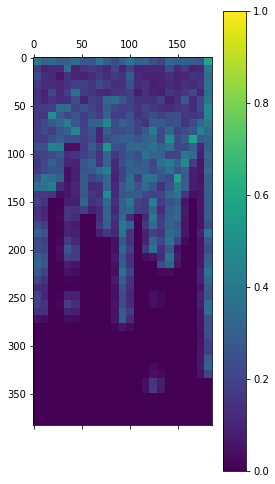

In [279]:
########### Non-responders' heatmap average ##############
heatmap_avg = np.empty(shape=(0,47,23))

for i in tqdm(range(len(X_nonresponder))):
    img = X_nonresponder[i].reshape(383,186,1)
    heatmap = make_grad_heatmap(img[np.newaxis], model, 'max_pooling2d_2')
    
    heatmap_avg = np.vstack([heatmap_avg, heatmap[None,:]])
    
non_heatmap_avg = np.nanmean(heatmap_avg, axis=0)

im = Image.fromarray(non_heatmap_avg)
im = im.resize((186,383), Image.NEAREST)

non_heatmap = np.array(im)

plt.matshow(im, vmin=0.0, vmax=1.0)
plt.colorbar()

In [240]:
# 데이터프레임 형태로 

non_heatmap_index_path = pd.DataFrame()

# res 0.9 이상 
non_heatmap_df = pd.DataFrame(non_heatmap, columns=pathway_list)
        
for index in range(len(non_heatmap_df)):
    for path in pathway_list:
        if non_heatmap_df.loc[index, path]>=0.5:
            index_path = pd.DataFrame([[index, path]],columns=['gene_index','pathway'])
            non_heatmap_index_path = pd.concat([non_heatmap_index_path, index_path], ignore_index=True)
        else: pass

# scale 값 0.9 이상인 pair dataframe
non_heatmap_index_path    

,gene_index,pathway
0,0,KEGG_FRUCTOSE_AND_MANNOSE_METABOLISM
1,0,KEGG_BLADDER_CANCER
2,0,KEGG_INSULIN_SIGNALING_PATHWAY
3,0,KEGG_CHEMOKINE_SIGNALING_PATHWAY
4,0,KEGG_PROTEASOME
...,...,...
323,129,KEGG_ADIPOCYTOKINE_SIGNALING_PATHWAY
324,129,KEGG_ALZHEIMERS_DISEASE
325,129,KEGG_VEGF_SIGNALING_PATHWAY
326,129,KEGG_ECM_RECEPTOR_INTERACTION


In [241]:
### image 길이에 맞춰서 편집

for i in tqdm(range(len(non_heatmap_index_path))):
    df = gene_pathway[gene_pathway['pathway']==non_heatmap_index_path.loc[i][1]].reset_index(drop=True)
    
    if non_heatmap_index_path.loc[i][0] < len(df): 
        non_heatmap_index_path.loc[i, 'gene'] = df['gene'][non_heatmap_index_path.loc[i][0]]
        
    else : pass

non_heatmap_index_path

100%|██████████| 328/328 [00:00<00:00, 912.00it/s]


,gene_index,pathway,gene
0,0,KEGG_FRUCTOSE_AND_MANNOSE_METABOLISM,MPI
1,0,KEGG_BLADDER_CANCER,HRAS
2,0,KEGG_INSULIN_SIGNALING_PATHWAY,GCK
3,0,KEGG_CHEMOKINE_SIGNALING_PATHWAY,CCL26
4,0,KEGG_PROTEASOME,PSMD11
...,...,...,...
323,129,KEGG_ADIPOCYTOKINE_SIGNALING_PATHWAY,NaN
324,129,KEGG_ALZHEIMERS_DISEASE,NDUFS1
325,129,KEGG_VEGF_SIGNALING_PATHWAY,NaN
326,129,KEGG_ECM_RECEPTOR_INTERACTION,NaN


In [242]:
### NaN 값 제외

print(non_heatmap_index_path.isna().sum())

selected_heatmap_nonresponder = non_heatmap_index_path.dropna(axis=0, how='any').reset_index(drop=True)
selected_heatmap_nonresponder

gene_index      0
pathway         0
gene          223
dtype: int64


,gene_index,pathway,gene
0,0,KEGG_FRUCTOSE_AND_MANNOSE_METABOLISM,MPI
1,0,KEGG_BLADDER_CANCER,HRAS
2,0,KEGG_INSULIN_SIGNALING_PATHWAY,GCK
3,0,KEGG_CHEMOKINE_SIGNALING_PATHWAY,CCL26
4,0,KEGG_PROTEASOME,PSMD11
...,...,...,...
100,125,KEGG_ALZHEIMERS_DISEASE,NDUFB10
101,126,KEGG_ALZHEIMERS_DISEASE,NDUFS8
102,127,KEGG_ALZHEIMERS_DISEASE,NDUFC1
103,128,KEGG_ALZHEIMERS_DISEASE,NDUFC2


In [243]:
### Non-responders' heatmap average 중 가장 많이 영향을 미친 gene-pathway
nonresponder_heatmap_dataframe = selected_heatmap_nonresponder[['gene','pathway']]
nonresponder_heatmap_dataframe

,gene,pathway
0,MPI,KEGG_FRUCTOSE_AND_MANNOSE_METABOLISM
1,HRAS,KEGG_BLADDER_CANCER
2,GCK,KEGG_INSULIN_SIGNALING_PATHWAY
3,CCL26,KEGG_CHEMOKINE_SIGNALING_PATHWAY
4,PSMD11,KEGG_PROTEASOME
...,...,...
100,NDUFB10,KEGG_ALZHEIMERS_DISEASE
101,NDUFS8,KEGG_ALZHEIMERS_DISEASE
102,NDUFC1,KEGG_ALZHEIMERS_DISEASE
103,NDUFC2,KEGG_ALZHEIMERS_DISEASE


In [251]:
nonresponder_heatmap_dataframe[:30]

,gene,pathway
0,MPI,KEGG_FRUCTOSE_AND_MANNOSE_METABOLISM
1,HRAS,KEGG_BLADDER_CANCER
2,GCK,KEGG_INSULIN_SIGNALING_PATHWAY
3,CCL26,KEGG_CHEMOKINE_SIGNALING_PATHWAY
4,PSMD11,KEGG_PROTEASOME
5,STAT3,KEGG_JAK_STAT_SIGNALING_PATHWAY
6,POLR2G,KEGG_PURINE_METABOLISM
7,CD80,KEGG_SYSTEMIC_LUPUS_ERYTHEMATOSUS
8,PMM2,KEGG_FRUCTOSE_AND_MANNOSE_METABOLISM
9,E2F1,KEGG_BLADDER_CANCER


In [278]:
nonresponder_heatmap_dataframe[['pathway','gene']].sort_values(by='pathway')

,pathway,gene
104,KEGG_ALZHEIMERS_DISEASE,NDUFS1
102,KEGG_ALZHEIMERS_DISEASE,NDUFC1
101,KEGG_ALZHEIMERS_DISEASE,NDUFS8
100,KEGG_ALZHEIMERS_DISEASE,NDUFB10
99,KEGG_ALZHEIMERS_DISEASE,MAPT
...,...,...
7,KEGG_SYSTEMIC_LUPUS_ERYTHEMATOSUS,CD80
55,KEGG_SYSTEMIC_LUPUS_ERYTHEMATOSUS,FCGR3B
39,KEGG_SYSTEMIC_LUPUS_ERYTHEMATOSUS,C9
23,KEGG_SYSTEMIC_LUPUS_ERYTHEMATOSUS,CD28


In [277]:
nonresponder_heatmap_dataframe[nonresponder_heatmap_dataframe['pathway']=='KEGG_CELL_CYCLE']

,gene,pathway
80,ANAPC4,KEGG_CELL_CYCLE
81,SMAD2,KEGG_CELL_CYCLE
82,YWHAQ,KEGG_CELL_CYCLE
83,CHEK2,KEGG_CELL_CYCLE
84,CDC23,KEGG_CELL_CYCLE
85,EP300,KEGG_CELL_CYCLE
86,GSK3B,KEGG_CELL_CYCLE
87,CDKN2A,KEGG_CELL_CYCLE
88,CDKN1C,KEGG_CELL_CYCLE
